# ¿Valen lo que cobran? Análisis de valor, rendimiento y carga de minutos en la NBA
## Contexto
Como analista de datos de los Golden State Warriors, el objetivo de este proyecto es identificar ineficiencias en el mercado de jugadores NBA y evaluar cómo la gestión de la carga de minutos afecta al rendimiento. El análisis usa datos de toda la liga para contextualizar las decisiones de roster de GSW.

## Fuentes de datos
- **Salarios y estadísticas básicas:** Kaggle (ratin21), basado en Basketball-Reference. Cubre temporadas 2010-2025.
- **Estadísticas avanzadas e históricas:** Kaggle (sumitrodatta), actualizado a temporada 2025-26.
- **Validación de salarios:** muestra contrastada contra Spotrac y HoopsHype.

## Limitación conocida
Los datos de salarios cubren hasta la temporada 2024-25, última temporada con datos contractuales completos y verificados. El análisis de rendimiento y carga de minutos incluye la temporada 2025-26.

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
# Dataset principal: salarios y estadísticas básicas por temporada (2010-2025).
df_salarios = pd.read_csv('data/NBA_Player_Stats_and_Salaries_2010-2025.csv')

# Estadísticas avanzadas históricas: PER, Win Shares, VORP, BPM (hasta 2026).
df_advanced = pd.read_csv('data/Advanced.csv')

# Totales por temporada: minutos acumulados, partidos jugados (hasta 2026).
df_totals = pd.read_csv('data/Player_Totals.csv')

# Resumen por equipo: victorias, ritmo, playoffs (hasta 2026).
df_equipos = pd.read_csv('data/Team_Summaries.csv')

## Fase 1: Exploración inicial
Antes de cualquier transformación, exploramos la estructura y calidad de cada dataset.

In [227]:
def explorar_dataset(df, nombre):
    # Muestra las dimensiones, tipos de datos, nulos y primeras filas del dataset.
    print(f'=== {nombre} ===')
    print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
    print()
    print('Tipos de datos:')
    print(df.dtypes)
    print()
    print('Valores nulos por columna:')
    nulos = df.isnull().sum()
    print(nulos[nulos > 0])
    print()
    print('Primeras filas:')
    display(df.head(3))
    print('---')

In [228]:
explorar_dataset(df_salarios, 'Salarios y stats básicas')
explorar_dataset(df_advanced, 'Estadísticas avanzadas')
explorar_dataset(df_totals, 'Totales por temporada')
explorar_dataset(df_equipos, 'Resumen por equipo')

=== Salarios y stats básicas ===
Filas: 7298 | Columnas: 31

Tipos de datos:
Player        str
Salary      int64
Year        int64
Pos           str
Age         int64
Team          str
G           int64
GS          int64
MP        float64
FG        float64
FGA       float64
FG%       float64
3P        float64
3PA       float64
3P%       float64
2P        float64
2PA       float64
2P%       float64
eFG%      float64
FT        float64
FTA       float64
FT%       float64
ORB       float64
DRB       float64
TRB       float64
AST       float64
STL       float64
BLK       float64
TOV       float64
PF        float64
PTS       float64
dtype: object

Valores nulos por columna:
FG%      20
3P%     585
2P%      45
eFG%     20
FT%     202
dtype: int64

Primeras filas:


,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Kobe Bryant,23034375,2010,SG,31,LAL,73,73,38.8,9.8,...,0.811,1.1,4.3,5.4,5.0,1.5,0.3,3.2,2.6,27.0
1,Jermaine O'Neal,23016000,2010,C,31,MIA,70,70,28.4,5.6,...,0.720,1.8,5.2,6.9,1.3,0.4,1.4,1.8,3.0,13.6
2,Tracy McGrady,22843124,2010,SG,30,NYK,30,24,22.4,3.0,...,0.746,0.7,2.4,3.1,3.3,0.5,0.5,1.5,1.3,8.2


---
=== Estadísticas avanzadas ===
Filas: 33339 | Columnas: 30

Tipos de datos:
season           int64
lg                 str
player             str
player_id          str
age            float64
team               str
pos                str
g                int64
gs             float64
mp             float64
per            float64
ts_percent     float64
x3p_ar         float64
f_tr           float64
orb_percent    float64
drb_percent    float64
trb_percent    float64
ast_percent    float64
stl_percent    float64
blk_percent    float64
tov_percent    float64
usg_percent    float64
ows            float64
dws            float64
ws             float64
ws_48          float64
obpm           float64
dbpm           float64
bpm            float64
vorp           float64
dtype: object

Valores nulos por columna:
age              20
pos            1197
gs             8155
mp             1083
per            1100
ts_percent      143
x3p_ar         6498
f_tr            164
orb_percent    5298
drb_perc

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,1745.0,...,9.0,17.6,1.8,1.2,2.9,0.081,-0.5,-1.1,-1.6,0.2
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,...,16.7,12.1,1.1,1.0,2.1,0.141,-0.1,-0.3,-0.5,0.3
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,...,8.3,25.0,2.8,3.6,6.4,0.129,1.5,0.4,2.0,2.4


---
=== Totales por temporada ===
Filas: 33339 | Columnas: 33

Tipos de datos:
season            int64
lg                  str
player              str
player_id           str
age             float64
team                str
pos                 str
g                 int64
gs              float64
mp              float64
fg                int64
fga               int64
fg_percent      float64
x3p             float64
x3pa            float64
x3p_percent     float64
x2p             float64
x2pa            float64
x2p_percent     float64
e_fg_percent    float64
ft                int64
fta               int64
ft_percent      float64
orb             float64
drb             float64
trb             float64
ast               int64
stl             float64
blk             float64
tov             float64
pf              float64
pts               int64
trp_dbl         float64
dtype: object

Valores nulos por columna:
age                20
pos              1197
gs               8155
mp               1083

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,73,57.0,1745.0,...,177.0,315.0,492.0,101,65.0,50.0,65.0,123.0,736,0.0
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,...,145.0,131.0,276.0,48,22.0,20.0,35.0,55.0,187,0.0
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,...,149.0,583.0,732.0,232,86.0,49.0,120.0,122.0,1468,0.0


---
=== Resumen por equipo ===
Filas: 1907 | Columnas: 31

Tipos de datos:
season                int64
lg                      str
team                    str
abbreviation            str
playoffs               bool
age                 float64
w                   float64
l                   float64
pw                  float64
pl                  float64
mov                 float64
sos                 float64
srs                 float64
o_rtg               float64
d_rtg               float64
n_rtg               float64
pace                float64
f_tr                float64
x3p_ar              float64
ts_percent          float64
e_fg_percent        float64
tov_percent         float64
orb_percent         float64
ft_fga              float64
opp_e_fg_percent    float64
opp_tov_percent     float64
drb_percent         float64
opp_ft_fga          float64
arena                   str
attend              float64
attend_g            float64
dtype: object

Valores nulos por columna:
abbreviation   

,season,lg,team,abbreviation,playoffs,age,w,l,pw,pl,...,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga,arena,attend,attend_g
0,2026,NBA,Atlanta Hawks,ATL,False,25.2,46.0,36.0,47.0,35.0,...,12.3,24.4,0.181,0.546,13.9,74.5,0.206,State Farm Arena,670581.0,16356.0
1,2026,NBA,Boston Celtics,BOS,False,26.9,56.0,26.0,59.0,23.0,...,11.2,29.2,0.167,0.523,11.4,75.7,0.189,TD Garden,785396.0,19156.0
2,2026,NBA,Brooklyn Nets,BRK,False,23.5,20.0,62.0,18.0,64.0,...,14.3,23.6,0.212,0.571,13.2,74.0,0.225,Barclays Center,713896.0,17412.0


---


### Observaciones tras la exploración inicial
- El dataset de salarios cubre las temporadas 2010-2025 con 7.298 filas y 31 columnas.
- Las columnas `3P%` (585 nulos), `FT%` (202 nulos), `FG%` (20 nulos) y `2P%` (45 nulos) presentan nulos esperados: el jugador no intentó ese tipo de tiro durante la temporada. No son errores, no se imputan.
- El dataset de estadísticas avanzadas incluye 33.339 filas hasta la temporada 2026. Las métricas `BPM`, `VORP` y porcentajes avanzados tienen miles de nulos correspondientes a temporadas anteriores a los años 70, cuando esas métricas no existían. Desaparecerán al filtrar por nuestro rango temporal desde 2010.
- `Player_Totals` tiene la misma estructura que `Advanced` (33.339 filas), con nulos históricos por el mismo motivo.
- `Team_Summaries` tiene 1.907 filas e incluye ligas históricas (ABA, BAA) además de la NBA. Se filtrará por `lg == 'NBA'` en la fase de limpieza.
- Los jugadores que cambiaron de equipo durante la temporada aparecen con varias filas en Advanced y Totals (una por equipo y una con el total `2TM`/`3TM`). Esto se gestionará en la fase de limpieza conservando únicamente la fila de totales.

## Fase 2: Limpieza y preparación de datos

La limpieza se aborda en tres pasos:
1. Filtrado por rango temporal y liga relevante para el análisis.
2. Gestión de nulos según su naturaleza.
3. Resolución de jugadores que cambiaron de equipo durante la temporada.

In [229]:
def limpiar_salarios(df):
    # Eliminamos duplicados exactos si los hubiera.
    df = df.drop_duplicates()
    
    # Renombramos columnas para homogeneizar con los otros datasets.
    df = df.rename(columns={
        'Player': 'player',
        'Year': 'season',
        'Team': 'team',
        'Pos': 'pos',
        'Age': 'age'
    })
       
    return df

df_salarios = limpiar_salarios(df_salarios)
print(f'Salarios limpio: {df_salarios.shape}')

Salarios limpio: (7298, 31)


In [230]:
def limpiar_advanced(df):
    # Filtramos solo NBA (el dataset incluye ABA y BAA).
    df = df[df['lg'] == 'NBA'].copy()
    
    # Filtramos el rango temporal relevante para el análisis.
    df = df[df['season'] >= 2010].copy()
    
    # Identificamos pares jugador+temporada que tienen fila multiteam (2TM, 3TM).
    # El filtro se aplica por jugador y temporada para no excluir temporadas en las que el jugador sí jugó en un solo equipo.
    multiteam_pares = df[df['team'].str.contains('TM', na=False)][['player','season']].copy()
    multiteam_pares['es_multiteam'] = True
    
    df = df.merge(multiteam_pares, on=['player','season'], how='left')
    
    # Para jugadores con fila total ese año: conservamos solo la fila total (2TM/3TM).
    # Para jugadores sin fila total ese año: conservamos su única fila de equipo.
    df = df[
        (df['es_multiteam'] == True) & (df['team'].str.contains('TM', na=False)) |
        (df['es_multiteam'].isna())
    ].copy()
    
    # Eliminamos columnas auxiliares y no necesarias para el análisis.
    df = df.drop(columns=['lg', 'es_multiteam'])
    
    return df

df_advanced = limpiar_advanced(df_advanced)
print(f'Advanced limpio: {df_advanced.shape}')

Advanced limpio: (8783, 29)


In [231]:
def limpiar_totals(df):
    # Filtramos solo NBA y rango temporal relevante para el análisis.
    df = df[df['lg'] == 'NBA'].copy()
    df = df[df['season'] >= 2010].copy()
    
    # Mismo criterio que en Advanced: identificamos multiteam por jugador y temporada para no excluir temporadas en las que el jugador jugó en un solo equipo.
    multiteam_pares = df[df['team'].str.contains('TM', na=False)][['player','season']].copy()
    multiteam_pares['es_multiteam'] = True
    
    df = df.merge(multiteam_pares, on=['player','season'], how='left')
    
    # Conservamos la fila total (2TM/3TM) cuando existe y la fila única en caso contrario.
    df = df[
        (df['es_multiteam'] == True) & (df['team'].str.contains('TM', na=False)) |
        (df['es_multiteam'].isna())
    ].copy()
    
    # Nos quedamos solo con las columnas necesarias para el análisis de carga de minutos.
    df = df[['season', 'player', 'team', 'g', 'mp']].copy()
    
    # Renombramos para distinguir de columnas homónimas en otros datasets.
    df = df.rename(columns={'g': 'partidos_totales', 'mp': 'minutos_totales'})
    
    return df

df_totals = limpiar_totals(df_totals)
print(f'Totals limpio: {df_totals.shape}')

Totals limpio: (8783, 5)


In [232]:
def limpiar_equipos(df):
    # Filtramos solo NBA.
    df = df[df['lg'] == 'NBA'].copy()
    
    # Filtramos rango temporal.
    df = df[df['season'] >= 2010].copy()
    
    # Nos quedamos con las columnas relevantes para el análisis de coaching.
    df = df[['season', 'team', 'abbreviation', 'playoffs', 'w', 'l', 'pace', 'n_rtg']].copy()
    
    return df

df_equipos = limpiar_equipos(df_equipos)
print(f'Equipos limpio: {df_equipos.shape}')

Equipos limpio: (527, 8)


### Resultados de la limpieza
- **Salarios:** 7.298 filas, 31 columnas. Sin cambios en dimensión, los nulos son estructurales y no requieren eliminación de filas.
- **Advanced:** de 33.339 filas históricas a 4.893 tras filtrar por NBA y temporadas desde 2010. Cubre las temporadas 2010-2026. Los jugadores multiteam quedan consolidados en una sola fila por temporada.
- **Totals:** misma estructura que Advanced tras la limpieza, 4.893 filas y 5 columnas con los minutos y partidos totales por temporada.
- **Equipos:** de 1.907 filas a 527 tras filtrar por NBA y temporadas desde 2010. Una fila por equipo por temporada.

## Fase 3: Construcción del dataset principal

Unimos los cuatro datasets en dos pasos:
1. Merge de salarios con advanced stats por jugador y temporada.
2. Incorporación de minutos totales desde Player_Totals.

In [233]:
def merge_salarios_advanced(df_sal, df_adv):
    # Seleccionamos columnas de advanced relevantes para el análisis.
    cols_advanced = ['season', 'player', 'player_id', 'team', 'per', 'ts_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']
    df_adv_final = df_adv[cols_advanced].copy()

    # Merge por jugador y temporada.
    # Usamos left join para conservar todos los registros de salarios.
    # Los jugadores sin match en advanced quedarán con NaN en métricas avanzadas.
    df = df_sal.merge(df_adv_final, on=['player', 'season'], how='left', suffixes=('', '_adv'))
    
    # Si team aparece duplicado por el merge, nos quedamos con el de salarios.
    if 'team_adv' in df.columns:
        df = df.drop(columns=['team_adv'])
    
    return df

df_merged = merge_salarios_advanced(df_salarios, df_advanced)
print(f'Tras merge salarios + advanced: {df_merged.shape}')
print(f'Nulos en ws tras merge: {df_merged["ws"].isnull().sum()}')

Tras merge salarios + advanced: (7302, 42)
Nulos en ws tras merge: 327


In [234]:
def incorporar_minutos(df_merged, df_tot):
    # Merge con los minutos totales por jugador y temporada.
    df = df_merged.merge(df_tot[['season', 'player', 'minutos_totales', 'partidos_totales']],
                         on=['player', 'season'], how='left')
    return df

df_merged = incorporar_minutos(df_merged, df_totals)
print(f'Tras incorporar minutos: {df_merged.shape}')
print(f'Nulos en minutos_totales: {df_merged["minutos_totales"].isnull().sum()}')

Tras incorporar minutos: (7310, 44)
Nulos en minutos_totales: 327


In [235]:
def verificar_merge(df):
    # Comprobamos si el merge ha generado duplicados en player+season.
    duplicados = df.duplicated(subset=['player', 'season'], keep=False)
    print(f'Filas con duplicados en player+season: {duplicados.sum()}')
    
    if duplicados.sum() > 0:
        # Mostramos los casos duplicados para entender su origen.
        print()
        print('Detalle de duplicados encontrados:')
        print(df[duplicados][['player', 'season', 'team', 'Salary', 'ws', 'minutos_totales']]
              .sort_values(['player', 'season'])
              .to_string())
    
    # Porcentaje de filas con Win Shares.
    cobertura_ws = (df['ws'].notna().sum() / len(df)) * 100
    print(f'\nCobertura de Win Shares: {cobertura_ws:.1f}%')
    
    # Porcentaje de filas con minutos totales.
    cobertura_min = (df['minutos_totales'].notna().sum() / len(df)) * 100
    print(f'Cobertura de minutos totales: {cobertura_min:.1f}%')
    
    # Muestra de jugadores conocidos para verificar que los datos tienen sentido.
    jugadores_test = ['LeBron James', 'Stephen Curry', 'Kevin Durant']
    print()
    print('Verificación manual de jugadores conocidos:')
    print(df[df['player'].isin(jugadores_test)][
        ['player', 'season', 'team', 'Salary', 'ws', 'minutos_totales']
    ].sort_values(['player', 'season']).to_string())

verificar_merge(df_merged)

Filas con duplicados en player+season: 16

Detalle de duplicados encontrados:
             player  season team  Salary   ws  minutos_totales
1745  Chris Johnson    2013  MEM   55718  1.0            284.0
1746  Chris Johnson    2013  MEM   55718  1.0            102.0
1747  Chris Johnson    2013  MEM   55718  0.2            284.0
1748  Chris Johnson    2013  MEM   55718  0.2            102.0
1749  Chris Johnson    2013  MIN   55718  1.0            284.0
1750  Chris Johnson    2013  MIN   55718  1.0            102.0
1751  Chris Johnson    2013  MIN   55718  0.2            284.0
1752  Chris Johnson    2013  MIN   55718  0.2            102.0
2119  Tony Mitchell    2014  DET  500000  0.2             79.0
2120  Tony Mitchell    2014  DET  500000  0.2             10.0
2121  Tony Mitchell    2014  DET  500000  0.1             79.0
2122  Tony Mitchell    2014  DET  500000  0.1             10.0
2123  Tony Mitchell    2014  MIL  500000  0.2             79.0
2124  Tony Mitchell    2014  MIL  500000

In [236]:
def crear_metricas_valor(df):
    # Salario en millones para que las cifras sean legibles.
    df['salario_millones'] = df['Salary'] / 1_000_000
    
    # Métrica principal: Win Shares por millón de dólares.
    # Mide cuántas victorias aporta el jugador por cada millón que cobra.
    df['ws_por_millon'] = df['ws'] / df['salario_millones']
    
    # Filtramos jugadores con menos de 10 partidos jugados para evitar que nos ensucien los datos por tener una muestra muy baja.
    df = df[df['G'] >= 10].copy()
    
    return df

df_merged = crear_metricas_valor(df_merged)
print(f'Dataset final tras filtro de minutos mínimos: {df_merged.shape}')
print(f'Rango de ws_por_millon: {df_merged["ws_por_millon"].min():.2f} a {df_merged["ws_por_millon"].max():.2f}')

Dataset final tras filtro de minutos mínimos: (6713, 46)
Rango de ws_por_millon: -17.12 a 29.25


In [237]:
def eliminar_duplicados_residuales(df):
    # Hemos visto que Chris Johnson (2013, MIN) y Tony Mitchell (2014, DET) generan duplicados: son jugadores distintos que comparten nombre, equipo y temporada en el dataset de salarios, pero que advanced distingue internamente por player_id.
    # El merge sin player_id cruza ambos registros de advanced con la única fila de salarios, generando combinaciones múltiples. Salarios no tiene player_id, así que no se puede hacer el merge con este dato.
    # Solución: ante duplicados en player+season, conservamos la fila con más minutos totales, que corresponde al jugador con mayor presencia real.
    df = df.sort_values('minutos_totales', ascending=False)
    df = df.drop_duplicates(subset=['player', 'season'], keep='first')
    df = df.sort_index().reset_index(drop=True)
    return df

df_merged = eliminar_duplicados_residuales(df_merged)
print(f'Shape tras eliminar duplicados: {df_merged.shape}')
print(f'Duplicados restantes: {df_merged.duplicated(subset=["player","season"]).sum()}')

Shape tras eliminar duplicados: (6707, 46)
Duplicados restantes: 0


In [238]:
# Para entender por qué existen duplicados en player+season, recurrimos a Player_Season_Info, que incluye player_id único por jugador.
df_psi = pd.read_csv('data/Player_Season_Info.csv')

casos = ['Chris Johnson', 'Tony Mitchell']
print('Player_id de los jugadores con nombre duplicado:')
print(df_psi[df_psi['player'].isin(casos)][['player', 'season', 'team', 'player_id']]
      .sort_values(['player', 'season'])
      .to_string())

Player_id de los jugadores con nombre duplicado:
              player  season team  player_id
23059  Chris Johnson    2011  2TM  johnsch03
23060  Chris Johnson    2011  BOS  johnsch03
23061  Chris Johnson    2011  POR  johnsch03
23643  Chris Johnson    2012  2TM  johnsch03
23644  Chris Johnson    2012  NOH  johnsch03
23645  Chris Johnson    2012  POR  johnsch03
24176  Chris Johnson    2013  MIN  johnsch03
24177  Chris Johnson    2013  MEM  johnsch04
24789  Chris Johnson    2014  BOS  johnsch04
25394  Chris Johnson    2015  3TM  johnsch04
25395  Chris Johnson    2015  MIL  johnsch04
25396  Chris Johnson    2015  PHI  johnsch04
25397  Chris Johnson    2015  UTA  johnsch04
26020  Chris Johnson    2016  UTA  johnsch04
24874  Tony Mitchell    2014  DET  mitchto02
24875  Tony Mitchell    2014  MIL  mitchto03


Los `player_id` distintos confirman que se trata de jugadores diferentes que comparten nombre y coincidieron en la misma temporada. Al hacer el merge por nombre y temporada sin disponer de un identificador único en el dataset de salarios, ambos registros de advanced se cruzan con la única fila de salarios, generando combinaciones múltiples.
Dado que no es posible separar ambos jugadores sin `player_id` en el dataset de salarios, conservamos la fila con más minutos totales, que corresponde al jugador con mayor presencia real en la temporada.

In [239]:
def eliminar_duplicados_residuales(df):
    df = df.sort_values('minutos_totales', ascending=False)
    df = df.drop_duplicates(subset=['player', 'season'], keep='first')
    df = df.sort_index().reset_index(drop=True)
    
    # Eliminamos player_id una vez resuelto el problema: no forma parte del análisis.
    df = df.drop(columns=['player_id'])
    
    return df

df_merged = eliminar_duplicados_residuales(df_merged)
print(f'Shape tras eliminar duplicados: {df_merged.shape}')
print(f'Duplicados restantes: {df_merged.duplicated(subset=["player","season"]).sum()}')

Shape tras eliminar duplicados: (6707, 45)
Duplicados restantes: 0


In [240]:
# Guardamos el dataset construido para no repetir el proceso en cada sesión.
df_merged.to_csv('data/nba_analisis_final.csv', index=False)
print('Dataset guardado en data/nba_analisis_final.csv')
print(f'Shape final: {df_merged.shape}')

Dataset guardado en data/nba_analisis_final.csv
Shape final: (6707, 45)


### Resultado de la construcción del dataset
El dataset final integra salarios, estadísticas básicas y métricas avanzadas para 6.707 registros a lo largo de 16 temporadas (2010-2025).

La cobertura de Win Shares es del 95.5%, suficiente para garantizar la solidez del análisis. Los 327 registros sin métricas avanzadas corresponden a jugadores con participación mínima en la temporada.

La métrica principal de valor es **Win Shares por millón de dólares** (`ws_por_millon`) mide cuántas victorias aporta un jugador por cada millón de dólares que cobra. Un valor alto indica un jugador infravalorado respecto a su contrato; un valor bajo, un jugador sobrepagado.

Se excluyen jugadores con menos de 10 partidos jugados en la temporada para garantizar significancia estadística en las métricas.

## Bloque 1: Análisis de mercado NBA
¿Qué jugadores ofrecen más valor respecto a su salario en toda la liga?

El objetivo de este bloque es identificar jugadores infravalorados y sobrepagados en el mercado NBA entre 2010 y 2025, usando Win Shares por millón de dólares como métrica principal de valor.

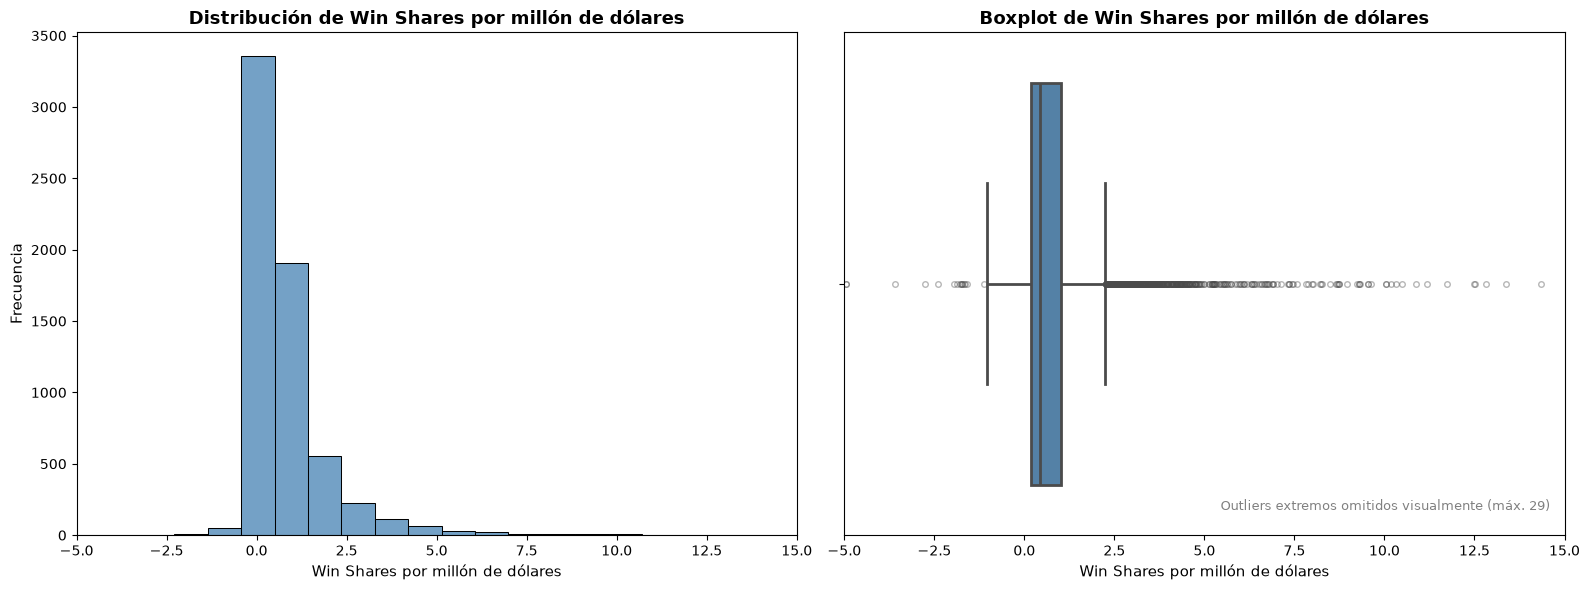

In [241]:
def ver_distribucion_num(df, columna, titulo):
    # Visualizamos la distribución de la métrica para detectar asimetrías y outliers
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histograma
    sns.histplot(data=df, x=columna, bins=50, ax=axes[0], color='steelblue')
    axes[0].set_xlim(-5, 15)  # excluimos outliers extremos para mayor legibilidad
    axes[0].set_title(f'Distribución de {titulo}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel(titulo, fontsize=11)
    axes[0].set_ylabel('Frecuencia', fontsize=11)
    axes[0].tick_params(labelsize=10)
    
    # Boxplot
    sns.boxplot(data=df, x=columna, ax=axes[1], color='steelblue',
                linewidth=2, flierprops=dict(marker='o', markersize=4, alpha=0.4))
    axes[1].set_xlim(-5, 15)
    axes[1].set_title(f'Boxplot de {titulo}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel(titulo, fontsize=11)
    axes[1].tick_params(labelsize=10)
    axes[1].annotate('Outliers extremos omitidos visualmente (máx. 29)',
                     xy=(0.98, 0.05), xycoords='axes fraction',
                     ha='right', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.show()

df_valor = df_merged[df_merged['ws_por_millon'].notna()].copy()
ver_distribucion_num(df_valor, 'ws_por_millon', 'Win Shares por millón de dólares')

### Distribución de Win Shares por millón de dólares

La distribución presenta una asimetría pronunciada hacia la derecha: la mayoría de jugadores se concentra entre -2 y 4 Win Shares por millón, pero existe una cola larga con valores que alcanzan hasta 29. Estos outliers positivos corresponden principalmente a jugadores jóvenes en contratos de rookie, que cobran salarios bajos respecto al rendimiento que aportan.

Los valores negativos indican jugadores cuya presencia en pista correlaciona con un peor rendimiento del equipo: su aportación en Win Shares es negativa, por lo que cualquier salario resulta excesivo respecto a su contribución real.

La concentración de la distribución en torno a 0-1 refleja que la mayoría de jugadores de la liga rinden de forma modesta en relación a lo que cobran, lo cual es esperable en una liga con salary cap estricto donde los contratos tienden a inflarse con el tiempo.

In [242]:
def clasificar_valor_mercado(df):
    # Calculamos los percentiles 33 y 66 para dividir en tres categorías.
    p33 = df['ws_por_millon'].quantile(0.33)
    p66 = df['ws_por_millon'].quantile(0.66)
    
    print(f'Percentil 33: {p33:.2f} ws/millón')
    print(f'Percentil 66: {p66:.2f} ws/millón')
    
    # Clasificamos cada jugador-temporada en tres categorías.
    def asignar_categoria(valor):
        if valor >= p66:
            return 'Infravalorado'      # rinde más de lo que cobra.
        elif valor >= p33:
            return 'Valor de mercado'   # rendimiento acorde al salario.
        else:
            return 'Sobrepagado'        # rinde menos de lo que cobra.
    
    df['categoria_valor'] = df['ws_por_millon'].apply(asignar_categoria)
    
    return df, p33, p66

df_valor, p33, p66 = clasificar_valor_mercado(df_valor)

print()
print('Distribución de categorías:')
print(df_valor['categoria_valor'].value_counts())

Percentil 33: 0.25 ws/millón
Percentil 66: 0.73 ws/millón

Distribución de categorías:
categoria_valor
Infravalorado       2173
Sobrepagado         2110
Valor de mercado    2109
Name: count, dtype: int64


### Clasificación por valor de mercado

Usando los percentiles 33 y 66 como umbrales, clasificamos cada registro en tres categorías:

- **Sobrepagado:** menos de 0.25 Win Shares por millón.
- **Valor de mercado:** entre 0.25 y 0.73 Win Shares por millón.
- **Infravalorado:** más de 0.73 Win Shares por millón.

La distribución es equilibrada por construcción al usar percentiles: aproximadamente un tercio de los registros cae en cada categoría. Lo relevante no es la distribución global sino qué jugadores y qué posiciones aparecen sistemáticamente en cada extremo.

In [243]:
def top_jugadores_por_valor(df, n=15, temporadas_recientes=None):
    # Filtramos jugadores con salario mínimo relevante para evitar contratos de dos vías que distorsionan la métrica
    df_filtrado = df[df['salario_millones'] >= 1].copy()
    
    # Si se especifica un rango de temporadas recientes, filtramos
    if temporadas_recientes:
        df_filtrado = df_filtrado[df_filtrado['season'] >= temporadas_recientes].copy()
    
    # Top jugadores infravalorados: mayor ws por millón
    top_infravalorados = (df_filtrado
                          .nlargest(n, 'ws_por_millon')
                          [['player', 'season', 'team', 'pos',
                            'salario_millones', 'ws', 'ws_por_millon']]
                          .reset_index(drop=True))
    
    # Top jugadores sobrepagados: menor ws por millón excluyendo ws negativos
    top_sobrepagados = (df_filtrado[df_filtrado['ws'] > 0]
                        .nsmallest(n, 'ws_por_millon')
                        [['player', 'season', 'team', 'pos',
                          'salario_millones', 'ws', 'ws_por_millon']]
                        .reset_index(drop=True))
    
    return top_infravalorados, top_sobrepagados

# Análisis histórico: patrones generales 2010-2025
print('=== ANÁLISIS HISTÓRICO (2010-2025) ===')
top_infra_hist, top_sobre_hist = top_jugadores_por_valor(df_valor, n=15)
print('TOP 15 INFRAVALORADOS:')
print(top_infra_hist.to_string())
print()
print('TOP 15 SOBREPAGADOS:')
print(top_sobre_hist.to_string())

print()
print('=== ANÁLISIS RECIENTE (2021-2025) ===')
top_infra_rec, top_sobre_rec = top_jugadores_por_valor(df_valor, n=15, temporadas_recientes=2021)
print('TOP 15 INFRAVALORADOS:')
print(top_infra_rec.to_string())
print()
print('TOP 15 SOBREPAGADOS:')
print(top_sobre_rec.to_string())

=== ANÁLISIS HISTÓRICO (2010-2025) ===
TOP 15 INFRAVALORADOS:
              player  season team pos  salario_millones    ws  ws_por_millon
0        Rudy Gobert    2015  UTA   C          1.127400   9.3       8.249069
1   Lance Stephenson    2014  IND  SG          1.005000   7.4       7.363184
2        Rudy Gobert    2017  UTA   C          2.121288  14.3       6.741187
3       Jimmy Butler    2014  CHI  SG          1.112880   7.1       6.379843
4        Serge Ibaka    2011  OKC  PF          1.204200   7.6       6.311244
5       Jimmy Butler    2013  CHI  SF          1.112880   7.0       6.289986
6        George Hill    2010  SAS  PG          1.081680   6.7       6.194068
7      Pascal Siakam    2019  TOR  PF          1.544951   9.3       6.019608
8     Kenneth Faried    2013  DEN  PF          1.311240   7.8       5.948568
9       Jimmy Butler    2015  CHI  SG          2.008748  11.2       5.575612
10     Nicolas Batum    2011  POR  SF          1.196760   6.6       5.514890
11       Rudy 

### Jugadores más infravalorados y sobrepagados (2010-2025)

El análisis se estructura en dos grupos con objetivos distintos. El análisis histórico (2010-2025) busca identificar patrones estructurales: qué perfiles de jugador tienden a estar infravalorados y qué tipos de contrato generan sobrepago de forma recurrente. 
El análisis reciente (2021-2025) tiene un objetivo operativo: identificar jugadores activos cuyo valor de mercado actual los convierte en objetivos de fichaje reales o en señales de alerta para la gestión del roster.

**Patrones históricos (2010-2025)**

El análisis histórico confirma un patrón estructural: los jugadores más infravalorados son consistentemente jóvenes en sus primeros contratos NBA, todavía con salario de rookie, rindiendo muy por encima de lo que cobran. Rudy Gobert aparece tres veces en el top 15 durante sus primeras temporadas en Utah, uno de los casos de infravaloración más prolongados y evidentes de la última década. Jimmy Butler repite también tres veces en Chicago antes de convertirse en uno de los jugadores mejor pagados de la liga.

Los jugadores más infravalorados del mercado no son agentes libres, son jugadores propios a los que hay que renovar antes de que lleguen a ser agentes libres.

En el lado opuesto, los sobrepagados comparten el mismo perfil: veteranos en el tramo final de contratos máximos firmados en su mejor momento, con rendimiento caído drásticamente mientras el salario permanece fijo. Los contratos máximos son el techo 
salarial que la NBA permite ofrecer a un jugador: equivalen aproximadamente al 25-35% del salary cap total del equipo, dependiendo de los años de experiencia del jugador. Se firman habitualmente en el mejor momento de la carrera de un jugador, pero al tener una duración de 3 a 5 años quedan desactualizados cuando el rendimiento cae por lesiones o edad. John Wall en 2023 con LAC es el caso más extremo: 50 millones por 0.3 Win Shares.

**Análisis reciente (2021-2025): objetivos accionables**

El jugador más infravalorado del mercado reciente es **Trayce Jackson-Davis en GSW durante 2024**: 4.8 Win Shares con un salario de 1.15 millones. Esto no es un hallazgo externo, es una señal interna: en GSW tenemos un jugador de alto valor en contrato de rookie que debe ser prioridad de renovación.

Entre los objetivos externos destacan **Mitchell Robinson** (NYK, 2022), **Jalen Brunson** (DAL, 2022) — antes de su renovación — y **Austin Reaves** (LAL), que aparece dos veces en el top 15. El patrón se repite: todos son jugadores jóvenes en primeros contratos con rendimiento muy superior a su salario.

En sobrepagados recientes, **Dejounte Murray en 2025** con NOP (29.5 millones, 0.2 Win Shares) y **Kyle Kuzma en 2024** con WAS (26.3 millones, 0.2 Win Shares) son los casos más llamativos. Ambos ilustran el riesgo de los contratos máximos firmados en base a temporadas aisladas de buen rendimiento.

**Nota sobre los contratos de dos vías**

Los registros con salarios inferiores a 1 millón de dólares han sido excluidos del análisis, ya que el salario mínimo en la NBA es 1 millón de dólares. Todos los jugadores que aparecen con un salario inferior al millón tienen firmado un contrato de dos vías. Los contratos de dos vías permiten a los equipos fichar jugadores de la G League (una liga por debajo de la NBA, que sirve como plataforma para jugadores jóvenes en desarrollo) por cantidades muy inferiores al mínimo NBA, lo que genera ratios de ws_por_millon artificialmente altos que distorsionan la métrica sin aportar información accionable sobre el mercado real de fichajes.

In [244]:
def valor_por_posicion(df):
    # Analizamos si hay posiciones sistemáticamente infravaloradas o sobrepagadas.
    resumen_posicion = (df.groupby('pos')['ws_por_millon']
                        .agg(['mean', 'median', 'count'])
                        .round(2)
                        .sort_values('median', ascending=False)
                        .reset_index())
    
    resumen_posicion.columns = ['pos', 'media', 'mediana', 'n_registros']
    print(resumen_posicion.to_string())
    
    return resumen_posicion

resumen_posicion = valor_por_posicion(df_valor)

      pos  media  mediana  n_registros
0    SF-C   0.59     0.59            1
1   SF-PF   1.23     0.54           12
2       C   0.96     0.54         1198
3   SG-PF   0.48     0.48            2
4      PF   0.83     0.46         1271
5      PG   0.82     0.43         1200
6      SF   0.83     0.42         1180
7      SG   0.78     0.41         1423
8   SG-PG   0.74     0.39           15
9   PG-SG   0.59     0.36           16
10   C-PF   0.80     0.36           14
11   PF-C   0.77     0.35           14
12  SF-SG   0.81     0.33           18
13  SG-SF   0.52     0.27           12
14  PF-SF   0.35     0.22           16


Los jugadores que juegan varias posiciones aparecen con etiquetas combinadas (SF-C, SG-PF, etc.) que fragmentan el análisis por posición. Vamos a normalizar las posiciones, agrupándolas en la posición principal, que es la primera que aparece.

In [245]:

def normalizar_posiciones(df):
    df['pos'] = df['pos'].str.split('-').str[0]
    return df

df_valor = normalizar_posiciones(df_valor)
print('Posiciones únicas tras normalización:')
print(df_valor['pos'].value_counts())

Posiciones únicas tras normalización:
pos
SG    1452
PF    1301
PG    1216
C     1212
SF    1211
Name: count, dtype: int64


In [246]:
resumen_posicion = valor_por_posicion(df_valor)

  pos  media  mediana  n_registros
0   C   0.96     0.53         1212
1  PF   0.82     0.46         1301
2  PG   0.82     0.43         1216
3  SF   0.84     0.43         1211
4  SG   0.77     0.41         1452


### Valor de mercado por posición (2010-2025)

Usando la mediana como referencia (es más fiable debido a los outliers) los pívots (C) son la posición con mayor valor de mercado por dólar invertido (0.53 ws/millón), seguidos de aleros (SF) y bases (PG) empatados en 0.43. Los escoltas (SG) son la posición sistemáticamente peor valorada en términos de rendimiento por salario (0.41 ws/millón).

Esto tiene una lectura directa para la gestión del roster: el mercado tiende a sobrepagar a los escoltas respecto a su aportación real en victorias, mientras que los pívots ofrecen históricamente el mejor retorno por dólar invertido. Para un equipo como GSW, que opera habitualmente cerca o por encima del límite del salary cap, esta diferencia entre posiciones es relevante a la hora de priorizar renovaciones y fichajes.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_30952\3155765730.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valor, y='pos', x='ws_por_millon',


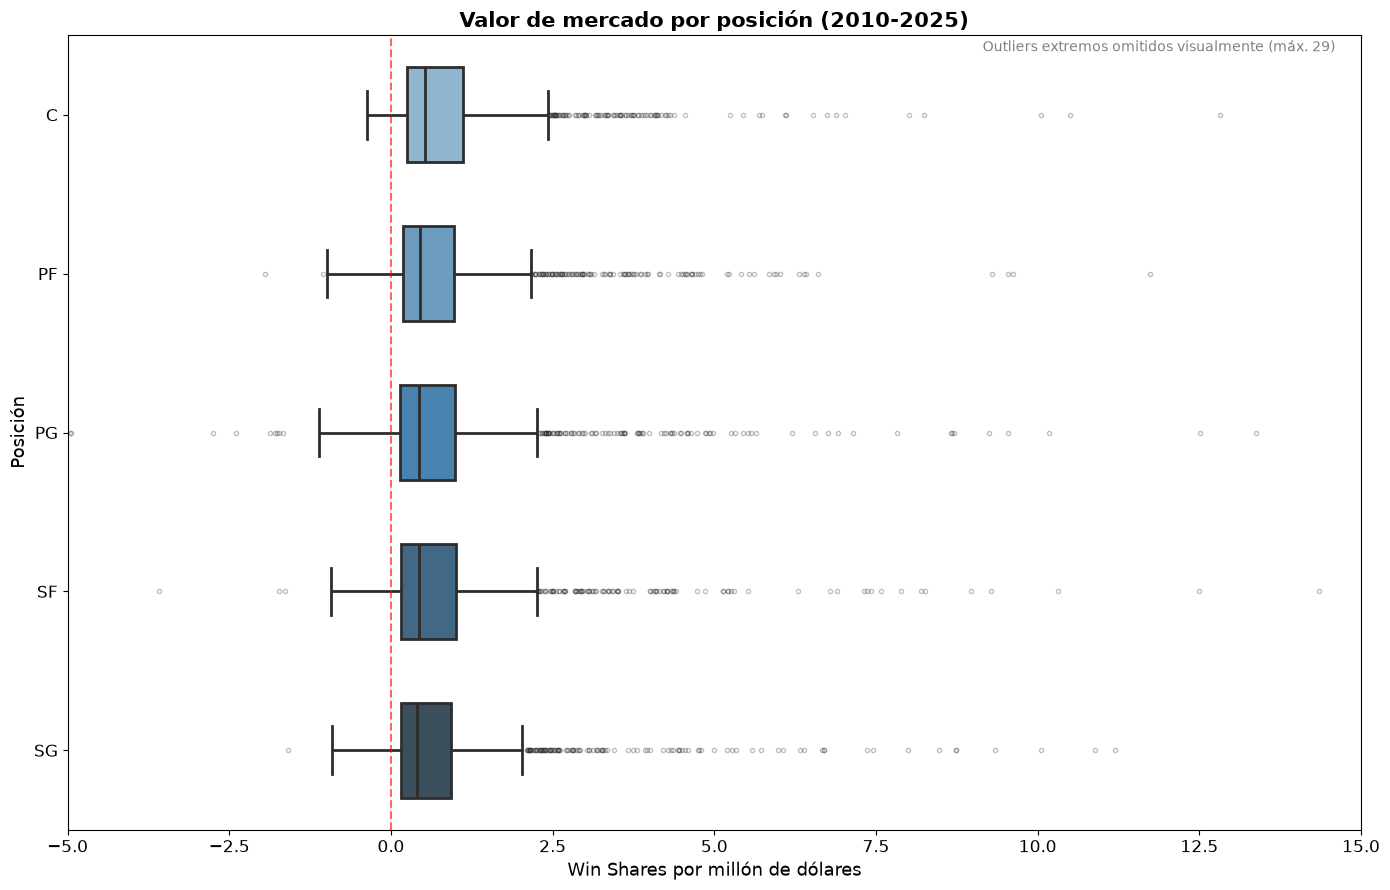

In [247]:
# Boxplot de ws_por_millon por posición para ver la dispersión dentro de cada una.
orden_posiciones = (df_valor.groupby('pos')['ws_por_millon']
                   .median()
                   .sort_values(ascending=False)
                   .index)

plt.figure(figsize=(14, 9))
sns.boxplot(data=df_valor, y='pos', x='ws_por_millon',
            order=orden_posiciones, palette='Blues_d',
            linewidth=2, width=0.6,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))
plt.axvline(x=0, color='red', linestyle='--', alpha=0.6, linewidth=1.5)  # línea de referencia en 0.
plt.xlim(-5, 15)  # limitamos el eje x para mayor legibilidad.
plt.title('Valor de mercado por posición (2010-2025)', fontsize=15, fontweight='bold')
plt.ylabel('Posición', fontsize=13)
plt.xlabel('Win Shares por millón de dólares', fontsize=13)
plt.tick_params(labelsize=12)
plt.annotate('Outliers extremos omitidos visualmente (máx. 29)',
             xy=(0.98, 0.98), xycoords='axes fraction',
             ha='right', fontsize=10, color='gray')
plt.tight_layout()
plt.show()

### Valor de mercado por posición (2010-2025)

Los pívots (C) presentan la mediana más alta de valor por dólar invertido, con la caja más desplazada hacia la derecha respecto al resto de posiciones. 
Los escoltas (SG) muestran la mediana más baja y la caja más concentrada cerca del cero, confirmando que es la posición donde el mercado tiende a sobrepagar de forma más consistente.

Las diferencias entre posiciones son moderadas pero sistemáticas a lo largo de 16 temporadas, lo que sugiere una ineficiencia estructural del mercado NBA: el talento en la posición de escolta se paga con una prima que no se refleja proporcionalmente en victorias. Para GSW, históricamente construido alrededor de escoltas de élite como Klay Thompson, esta es una señal relevante a la hora de evaluar el coste de oportunidad de esos contratos.

Todas las posiciones presentan una cola larga de outliers positivos, correspondientes a jugadores jóvenes en contratos de rookie con rendimiento muy superior a su salario, patrón ya identificado en el análisis anterior.

In [248]:
# Seleccionamos las columnas relevantes para el dashboard de mercado en Power BI
cols_mercado = ['player', 'season', 'team', 'pos', 'age',
                'salario_millones', 'ws', 'ws_por_millon',
                'per', 'vorp', 'categoria_valor']

df_mercado_pbi = df_valor[cols_mercado].copy()
df_mercado_pbi.to_csv('data/pbi_mercado_nba.csv', index=False, decimal=',')
print(f'Exportado: data/pbi_mercado_nba.csv')
print(f'Shape: {df_mercado_pbi.shape}')

Exportado: data/pbi_mercado_nba.csv
Shape: (6392, 11)


### Conclusiones del Bloque 1: Mercado NBA

Tres conclusiones accionables para GSW:

1. **El jugador infravalorado no está en la agencia libre, está en el propio roster.** 
   El perfil histórico sistemático es el jugador joven en contrato de rookie rindiendo por encima de su salario. Trayce Jackson-Davis en 2024 es el ejemplo más reciente y directo para GSW.

2. **Los pívots ofrecen el mejor retorno por dólar invertido.** 
   En un mercado donde GSW históricamente ha invertido mucho en escoltas de élite, los datos sugieren que la posición de pívot está estructuralmente infravalorada por el mercado y ofrece mayor margen de eficiencia.

3. **Los contratos máximos a veteranos son el principal riesgo de sobrepago.** 
   Los casos más extremos de la serie histórica comparten el mismo patrón: jugadores que firmaron contratos máximos en su mejor momento y cuyo rendimiento cayó mientras el salario permanecía fijo. GSW debe evaluar sus renovaciones con especial cautela en jugadores mayores de 30 años.

## Bloque 2: Análisis del roster de Golden State Warriors

¿Cómo está gestionando GSW su salary cap? ¿Tiene jugadores infravalorados que renovar con urgencia o contratos que lastran el roster?

Filtramos el dataset a los jugadores que han vestido la camiseta de GSW entre 2021 y 2025 y los comparamos contra la media de la liga.

In [249]:
def filtrar_roster_gsw(df):
    df_gsw = df[(df['team'] == 'GSW') & (df['season'] >= 2021)].copy()
    
    print(f'Registros GSW (2021-2025): {df_gsw.shape[0]}')
    print(f'Temporadas cubiertas: {sorted(df_gsw.season.unique())}')
    print(f'Jugadores únicos: {df_gsw.player.nunique()}')
    
    return df_gsw

df_gsw = filtrar_roster_gsw(df_valor)

Registros GSW (2021-2025): 70
Temporadas cubiertas: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Jugadores únicos: 36


### Roster GSW (2021-2025)

El análisis cubre 70 registros correspondientes a 36 jugadores distintos que han vestido la camiseta de GSW en las últimas 5 temporadas. 
La rotación es elevada, lo cual es habitual en equipos que operan cerca del salary cap y recurren a contratos cortos para gestionar la flexibilidad financiera.

In [250]:
def comparar_gsw_vs_liga(df_liga, df_gsw):
    # Calculamos las métricas medias de GSW y de la liga para comparar
    metricas = ['salario_millones', 'ws', 'ws_por_millon', 'per']
    
    resumen_liga = df_liga[df_liga['season'] >= 2021][metricas].median().round(2)
    resumen_gsw = df_gsw[metricas].median().round(2)
    
    comparacion = pd.DataFrame({
        'Liga (mediana)': resumen_liga,
        'GSW (mediana)': resumen_gsw,
        'Diferencia': (resumen_gsw - resumen_liga).round(2)
    })
    
    print(comparacion.to_string())
    return comparacion

comparacion = comparar_gsw_vs_liga(df_valor, df_gsw)

                  Liga (mediana)  GSW (mediana)  Diferencia
salario_millones            4.60           5.41        0.81
ws                          1.80           2.90        1.10
ws_por_millon               0.29           0.41        0.12
per                        13.20          14.05        0.85


### GSW vs liga (2021-2025)

GSW paga más que la media de la liga (5.41M vs 4.60M de mediana salarial), pero obtiene más rendimiento: sus jugadores aportan más Win Shares (2.90 vs 1.80), tienen mejor eficiencia individual (PER 14.05 vs 13.20) y ofrecen mejor valor por dólar invertido (0.41 vs 0.29 ws/millón).

En conjunto, GSW es un equipo que gasta por encima de la media pero con un retorno superior al mercado. Esto sugiere una gestión eficiente del roster en el período analizado, aunque el salary cap comprometido que vimos al inicio del análisis indica que esa eficiencia tiene un límite estructural: queda poco margen para incorporar nuevo talento sin sacrificar jugadores actuales.

In [251]:
def clasificar_jugadores_gsw(df_gsw, p33, p66):
    # Aplicamos los mismos umbrales de clasificación del Bloque 1 para que los jugadores de GSW sean comparables con el resto de la liga.
    # Excluimos contratos de dos vías y mínimos que distorsionan la métrica.
    df_gsw = df_gsw[df_gsw['salario_millones'] >= 1].copy()
    
    def asignar_categoria(valor):
        if valor >= p66:
            return 'Infravalorado'
        elif valor >= p33:
            return 'Valor de mercado'
        else:
            return 'Sobrepagado'
    
    df_gsw['categoria_valor'] = df_gsw['ws_por_millon'].apply(asignar_categoria)
    
    detalle = (df_gsw[['player', 'season', 'pos', 'salario_millones',
                        'ws', 'ws_por_millon', 'categoria_valor']]
               .sort_values('ws_por_millon', ascending=False)
               .reset_index(drop=True))
    
    print(detalle.to_string())
    return detalle

detalle_gsw = clasificar_jugadores_gsw(df_gsw, p33, p66)

                   player  season pos  salario_millones   ws  ws_por_millon   categoria_valor
0    Trayce Jackson-Davis    2024  PF          1.152829  4.8       4.163670     Infravalorado
1          Gary Payton II    2022  PG          1.930149  5.2       2.694093     Infravalorado
2   Juan Toscano-Anderson    2021  SG          1.150399  3.0       2.607791     Infravalorado
3            Jordan Poole    2022  SG          2.499375  6.0       2.400600     Infravalorado
4    Trayce Jackson-Davis    2025   C          1.891857  3.4       1.797176     Infravalorado
5              Damion Lee    2021  SG          2.148304  2.7       1.256805     Infravalorado
6         Nemanja Bjelica    2022   C          2.416128  3.0       1.241656     Infravalorado
7              Damion Lee    2022  SG          2.209618  2.7       1.221931     Infravalorado
8      Brandin Podziemski    2025  SG          3.519960  4.2       1.193195     Infravalorado
9      Brandin Podziemski    2024  SG          3.452017  4.1

### Clasificación individual de jugadores GSW (2021-2025)

El análisis individual revela una división clara en el roster de GSW entre dos grupos bien diferenciados.

**Jugadores infravalorados: el valor oculto del roster**

Trayce Jackson-Davis en 2024 encabeza la lista con 4.16 ws/millón, el mejor ratio de todo el roster. Brandin Podziemski aparece dos veces consecutivas (2024 y 2025), señal de que su infravaloración no es puntual sino sostenida. Kevon Looney aparece también como infravalorado en 2022 y 2023, antes de que su salario aumentara hasta los 8 millones en temporadas posteriores, donde pasa a valor de mercado. Es el ejemplo perfecto de un jugador al que GSW renovó en el momento adecuado.

Jonathan Kuminga merece atención especial: aparece como infravalorado en 2024 (6.19M, 4.6 ws) pero cae a valor de mercado en 2025 con un salario similar. Su trayectoria está en un punto de inflexión.

**Jugadores sobrepagados: el coste del ciclo ganador**

Los sobrepagados son exactamente los jugadores del núcleo del ciclo de campeonatos de GSW: Stephen Curry, Klay Thompson, Draymond Green y Andrew Wiggins aparecen de forma recurrente en esta categoría. Esto no es una señal de mala gestión sino la consecuencia inevitable de mantener a los artífices de cuatro campeonatos con contratos máximos mientras su rendimiento por dólar cae con la edad.

Klay Thompson es el caso más extremo: 43-44 millones con Win Shares entre 1.8 y 3.6, los ratios más bajos del roster. Jimmy Butler en 2025 con 48.8 millones y 8.7 Win Shares es el fichaje más caro del período analizado y, pese a ser el que más victorias aporta en términos absolutos, su ratio de 0.178 ws/millón lo sitúa como sobrepagado respecto al mercado.

**Lectura global**

GSW está en una transición entre dos eras: los jugadores jóvenes (Jackson-Davis, Podziemski, Kuminga) ofrecen un retorno muy superior al de los veteranos que construyeron la dinastía. La gestión del salary cap en los próximos años dependerá de la capacidad del equipo para equilibrar el peso contractual de los veteranos con las renovaciones de los jugadores jóvenes antes de que lleguen a la agencia libre.

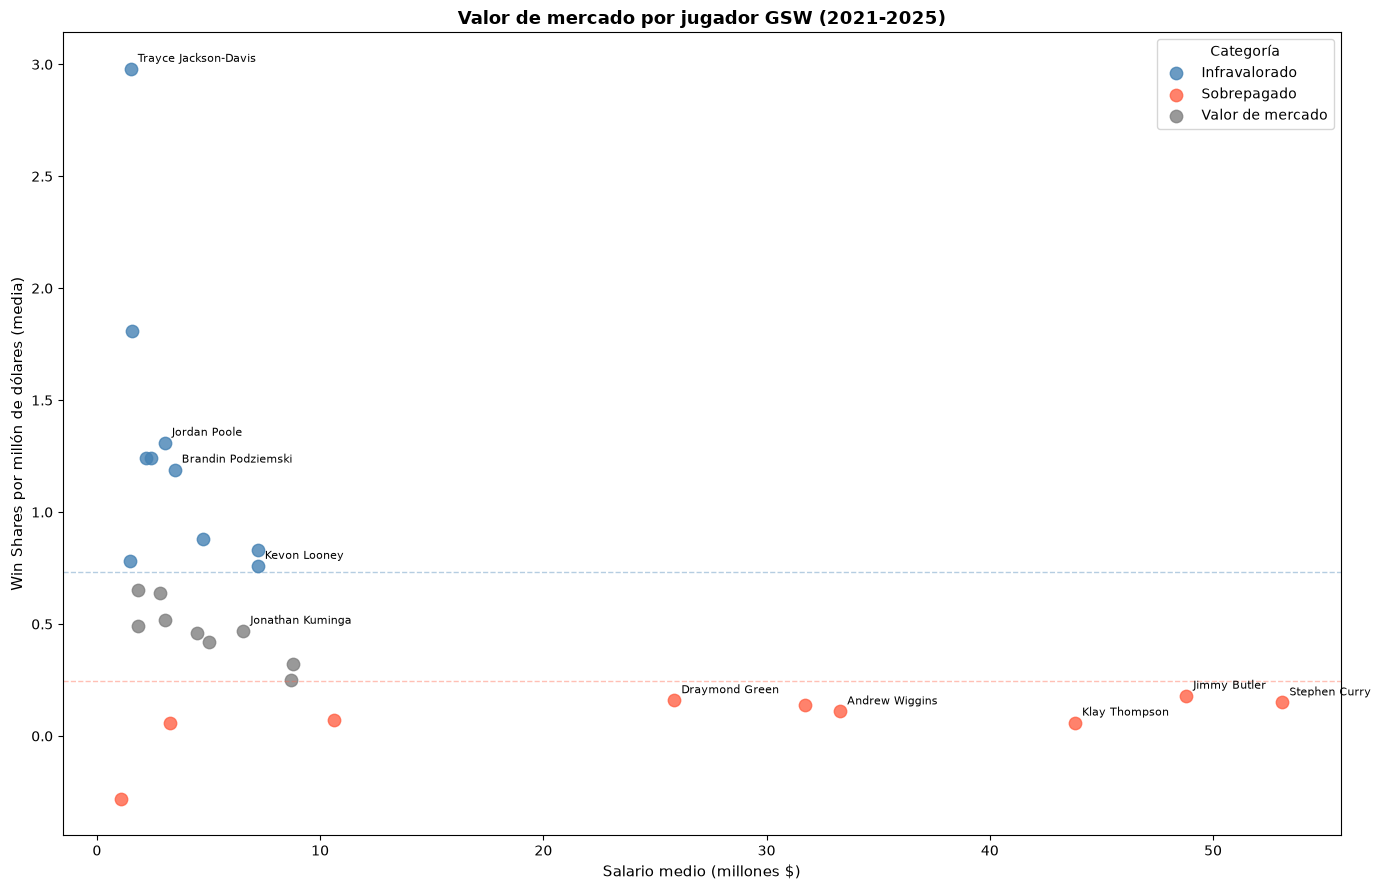

In [252]:
# Calculamos la media de ws_por_millon por jugador para tener un valor representativo de su trayectoria en GSW y evitar que un jugador aparezca varias veces en el gráfico.
df_gsw_media = (detalle_gsw.groupby('player')
                .agg(
                    salario_millones=('salario_millones', 'mean'),
                    ws_por_millon=('ws_por_millon', 'mean'),
                    ws=('ws', 'mean'),
                    pos=('pos', 'first')  # conservamos la posición más frecuente
                )
                .round(2)
                .reset_index())

# Clasificamos con los mismos umbrales para el gráfico.
def asignar_categoria(valor):
    if valor >= p66:
        return 'Infravalorado'
    elif valor >= p33:
        return 'Valor de mercado'
    else:
        return 'Sobrepagado'

df_gsw_media['categoria_valor'] = df_gsw_media['ws_por_millon'].apply(asignar_categoria)

# Scatter plot: salario vs ws_por_millon con jugadores etiquetados.
plt.figure(figsize=(14, 9))
colores = {'Infravalorado': 'steelblue', 'Valor de mercado': 'gray', 'Sobrepagado': 'tomato'}

for categoria, grupo in df_gsw_media.groupby('categoria_valor'):
    plt.scatter(grupo['salario_millones'], grupo['ws_por_millon'],
                color=colores[categoria], label=categoria, s=80, alpha=0.8)

# Etiquetamos solo los jugadores más relevantes para no saturar el gráfico.
jugadores_etiquetar = ['Stephen Curry', 'Klay Thompson', 'Draymond Green',
                       'Trayce Jackson-Davis', 'Brandin Podziemski',
                       'Jonathan Kuminga', 'Andrew Wiggins', 'Jimmy Butler',
                       'Kevon Looney', 'Jordan Poole']

for _, row in df_gsw_media[df_gsw_media['player'].isin(jugadores_etiquetar)].iterrows():
    plt.annotate(row['player'],
                 xy=(row['salario_millones'], row['ws_por_millon']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.axhline(y=p66, color='steelblue', linestyle='--', alpha=0.4, linewidth=1)
plt.axhline(y=p33, color='tomato', linestyle='--', alpha=0.4, linewidth=1)
plt.title('Valor de mercado por jugador GSW (2021-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Salario medio (millones $)', fontsize=11)
plt.ylabel('Win Shares por millón de dólares (media)', fontsize=11)
plt.legend(title='Categoría', fontsize=10)
plt.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

Veo que hay puntos en posiciones relevantes sin etiqueta, vamos a etiquetar todos los puntos para que el análisis tenga más valor

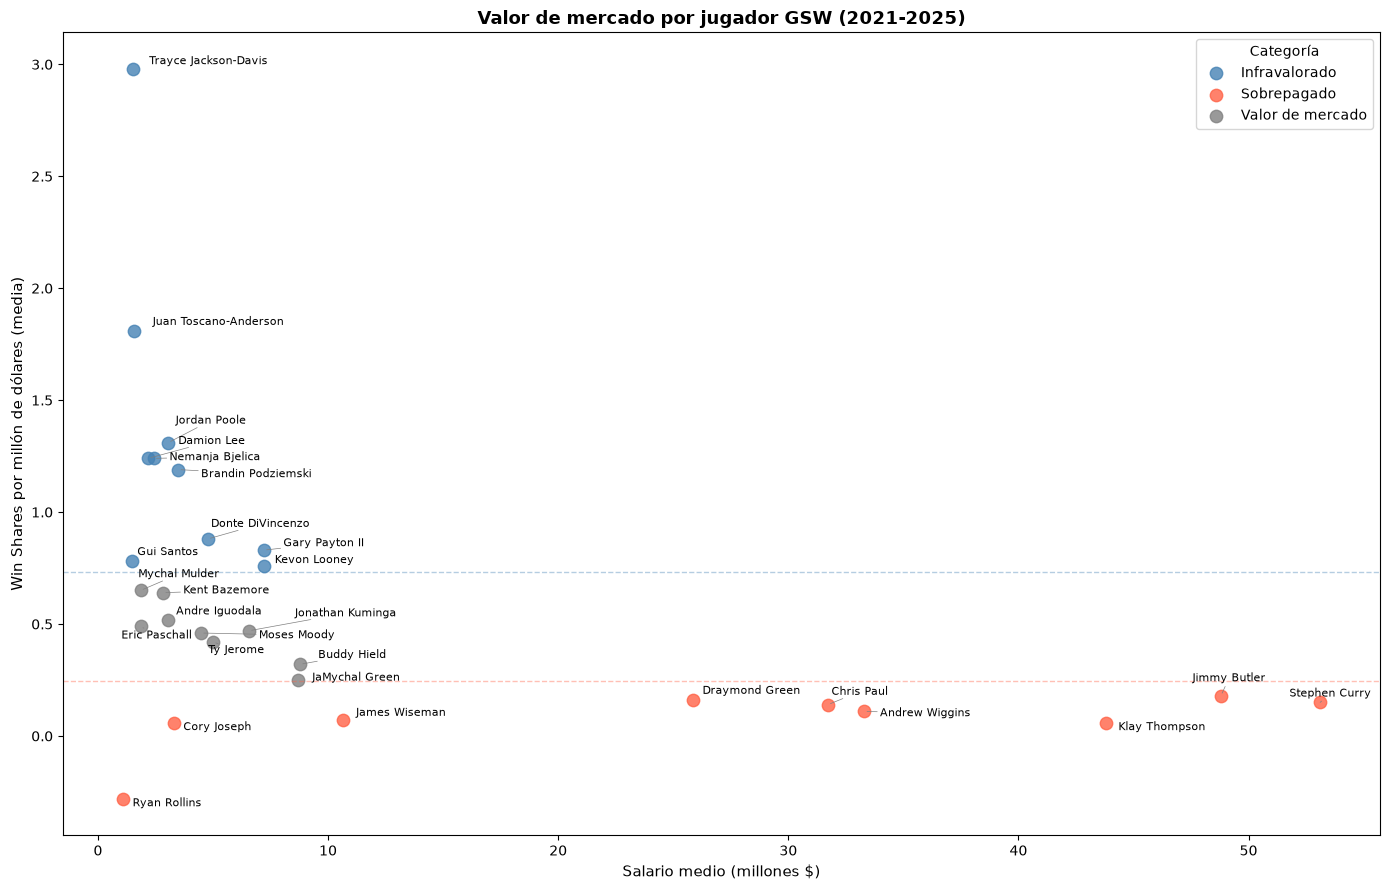

In [253]:
from adjustText import adjust_text

plt.figure(figsize=(14, 9))
colores = {'Infravalorado': 'steelblue', 'Valor de mercado': 'gray', 'Sobrepagado': 'tomato'}

for categoria, grupo in df_gsw_media.groupby('categoria_valor'):
    plt.scatter(grupo['salario_millones'], grupo['ws_por_millon'],
                color=colores[categoria], label=categoria, s=80, alpha=0.8)

# Etiquetamos todos los jugadores.
texts = []
for _, row in df_gsw_media.iterrows():
    texts.append(plt.annotate(row['player'],
                              xy=(row['salario_millones'], row['ws_por_millon']),
                              fontsize=8))

# Recolocamos automáticamente las etiquetas para evitar solapamientos.
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.axhline(y=p66, color='steelblue', linestyle='--', alpha=0.4, linewidth=1)
plt.axhline(y=p33, color='tomato', linestyle='--', alpha=0.4, linewidth=1)
plt.title('Valor de mercado por jugador GSW (2021-2025)', fontsize=13, fontweight='bold')
plt.xlabel('Salario medio (millones $)', fontsize=11)
plt.ylabel('Win Shares por millón de dólares (media)', fontsize=11)
plt.legend(title='Categoría', fontsize=10)
plt.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

### Scatter plot: salario vs valor de mercado en GSW (2021-2025)

El gráfico ilustra de forma visual la dualidad del roster de GSW. La esquina superior izquierda concentra los jugadores jóvenes con salarios bajos y alto retorno: Trayce Jackson-Davis lidera claramente este grupo, seguido de Juan Toscano-Anderson, Jordan Poole, Brandin Podziemski y Kevon Looney. Son los jugadores que más valor aportan por dólar invertido.

La esquina inferior derecha cuenta la historia opuesta: Stephen Curry, Klay Thompson, Jimmy Butler, Andrew Wiggins y Draymond Green concentran la mayor parte del salary cap con ratios de valor cercanos a cero. La línea discontinua roja marca el umbral de sobrepago: todos ellos quedan por debajo.

Jonathan Kuminga aparece en una posición intermedia, cerca del umbral de infravalorado pero sin superarlo en media. Es el jugador con mayor incertidumbre del roster: si confirma su progresión, GSW tiene un activo de alto valor. Si se estanca, su próximo contrato puede convertirle en el siguiente sobrepagado de la lista.

Las líneas discontinuas marcan los umbrales de clasificación calculados en el Bloque 1 sobre toda la liga, lo que permite comparar directamente a cada jugador de GSW contra el mercado NBA en su conjunto.

In [254]:
# Exportamos dos tablas para el dashboard de GSW en Power BI: el detalle por jugador y temporada, y la media por jugador para el scatter plot.

# Tabla 1: detalle por jugador y temporada
detalle_gsw.to_csv('data/pbi_roster_gsw_detalle.csv', index=False, decimal=',')
print(f'Exportado: data/pbi_roster_gsw_detalle.csv')
print(f'Shape: {detalle_gsw.shape}')

# Tabla 2: media por jugador para el scatter plot
df_gsw_media.to_csv('data/pbi_roster_gsw_media.csv', index=False, decimal=',')
print(f'Exportado: data/pbi_roster_gsw_media.csv')
print(f'Shape: {df_gsw_media.shape}')

Exportado: data/pbi_roster_gsw_detalle.csv
Shape: (61, 7)
Exportado: data/pbi_roster_gsw_media.csv
Shape: (28, 6)


### Conclusiones del Bloque 2: Roster GSW

Tres conclusiones accionables:

1. **Prioridad de renovación: Trayce Jackson-Davis y Brandin Podziemski.** 
   Son los dos jugadores con mejor ratio de valor del roster y ambos están en contratos de rookie. Renovarlos antes de que lleguen a la agencia libre es la decisión más urgente.

2. **Jonathan Kuminga es la decisión más difícil.** 
   Su rendimiento por dólar está en el umbral entre infravalorado y valor de mercado. La próxima temporada definirá si merece un contrato máximo o uno de mercado medio.

3. **El peso contractual de la era dorada es el principal lastre.** 
   Curry, Thompson, Green y Wiggins concentran más del 60% del salary cap con ratios de valor entre los más bajos del roster. GSW no puede construir el futuro sin gestionar la transición de estos contratos.

## Bloque 3: Gestión de carga de minutos

¿Cómo gestiona el coaching staff de GSW los minutos de sus jugadores comparado con el resto de equipos de la liga? ¿Hay correlación entre la acumulación de minutos y la caída de rendimiento?

Este bloque analiza la distribución de minutos por equipo y evalúa si una mayor rotación se traduce en un rendimiento más estable a lo largo de la temporada.

In [255]:
def preparar_dataset_minutos(df_merged, df_equipos):
    # Seleccionamos las columnas relevantes para el análisis de carga.
    cols = ['player', 'season', 'team', 'pos', 'age',
            'minutos_totales', 'partidos_totales', 'ws', 'per']
    
    df_min = df_merged[cols].copy()
    
    # Filtramos jugadores con menos de 10 partidos para eliminar ruido estadístico.
    df_min = df_min[df_min['partidos_totales'] >= 10].copy()
    
    # Calculamos minutos por partido como indicador de carga individual.
    df_min['minutos_por_partido'] = (df_min['minutos_totales'] / 
                                     df_min['partidos_totales']).round(1)
    
    # Incorporamos el número de victorias del equipo para contextualizar.
    df_min = df_min.merge(df_equipos[['season', 'team', 'w', 'pace']],
                          on=['season', 'team'], how='left')
    
    print(f'Dataset de minutos: {df_min.shape}')
    print(f'Nulos en minutos_totales: {df_min["minutos_totales"].isnull().sum()}')
    
    return df_min

df_minutos = preparar_dataset_minutos(df_merged, df_equipos)

Dataset de minutos: (6392, 12)
Nulos en minutos_totales: 0


### Dataset de carga de minutos

La métrica principal de este bloque es **minutos por partido**, mide la carga individual que el coaching staff asigna a cada jugador en cada temporada, y permite comparar la gestión de rotaciones entre equipos con independencia del número de partidos jugados.

In [256]:
def carga_media_por_equipo(df_min, temporadas_recientes=2021):
    # Calculamos la carga media de minutos por partido para cada equipo filtrando solo temporadas recientes.
    df_reciente = df_min[df_min['season'] >= temporadas_recientes].copy()
    
    carga_equipo = (df_reciente.groupby('team')
                   .agg(
                       minutos_por_partido=('minutos_por_partido', 'mean'),
                       jugadores=('player', 'nunique'),
                       ws_medio=('ws', 'mean')
                   )
                   .round(2)
                   .sort_values('minutos_por_partido', ascending=False)
                   .reset_index())
    
    print(carga_equipo.to_string())
    return carga_equipo

carga_equipo = carga_media_por_equipo(df_minutos)

   team  minutos_por_partido  jugadores  ws_medio
0   NOP                22.64         34      2.14
1   BRK                22.35         45      2.41
2   LAC                21.91         41      3.19
3   NYK                21.88         40      3.29
4   MIA                21.80         40      2.82
5   IND                21.65         39      2.65
6   OKC                21.54         38      2.72
7   POR                21.32         44      1.75
8   PHO                21.22         44      3.11
9   CHO                21.21         36      1.69
10  TOR                21.09         46      2.29
11  CLE                21.05         45      2.90
12  LAL                21.05         51      2.63
13  DET                20.94         49      1.57
14  ATL                20.82         39      2.68
15  MEM                20.78         36      2.66
16  GSW                20.77         36      3.15
17  MIL                20.76         40      3.19
18  ORL                20.65         32      1.99


In [257]:
print(f'Media de la liga (minutos por partido): {carga_equipo["minutos_por_partido"].mean():.2f}')
print(f'Posición de GSW: {carga_equipo[carga_equipo["team"]=="GSW"].index[0]+1} de {len(carga_equipo)}')
print(f'Media de la liga (ws_medio): {carga_equipo["ws_medio"].mean():.2f}')
print(f'GSW ws_medio: {carga_equipo[carga_equipo["team"]=="GSW"]["ws_medio"].values[0]:.2f}')

Media de la liga (minutos por partido): 20.87
Posición de GSW: 17 de 30
Media de la liga (ws_medio): 2.52
GSW ws_medio: 3.15


### Carga media de minutos por equipo (2021-2025)

La media de la liga es de 20.87 minutos por partido. GSW se sitúa en el puesto 17 de 30 con 20.77 minutos por partido, ligeramente por debajo de la media, lo que indica una rotación algo más amplia que la media de la liga.

Lo más relevante no es la posición en el ranking de minutos sino la combinación de dos métricas: GSW es uno de los equipos que menos carga impone a sus jugadores individualmente y al mismo tiempo obtiene un ws_medio de 3.15, por encima de la media de la liga (2.52). 

Equipos como NOP o BRK, que lideran el ranking de minutos por partido, obtienen ws_medio de 2.14 y 2.41 respectivamente, por debajo de la media. En el extremo opuesto, DEN carga menos minutos por jugador (18.78) pero también obtiene un ws_medio bajo (2.30), lo que sugiere una rotación excesivamente amplia que diluye el rendimiento individual.

GSW parece haber encontrado un equilibrio entre rotación y rendimiento que se traduce en eficiencia superior a la media de la liga.

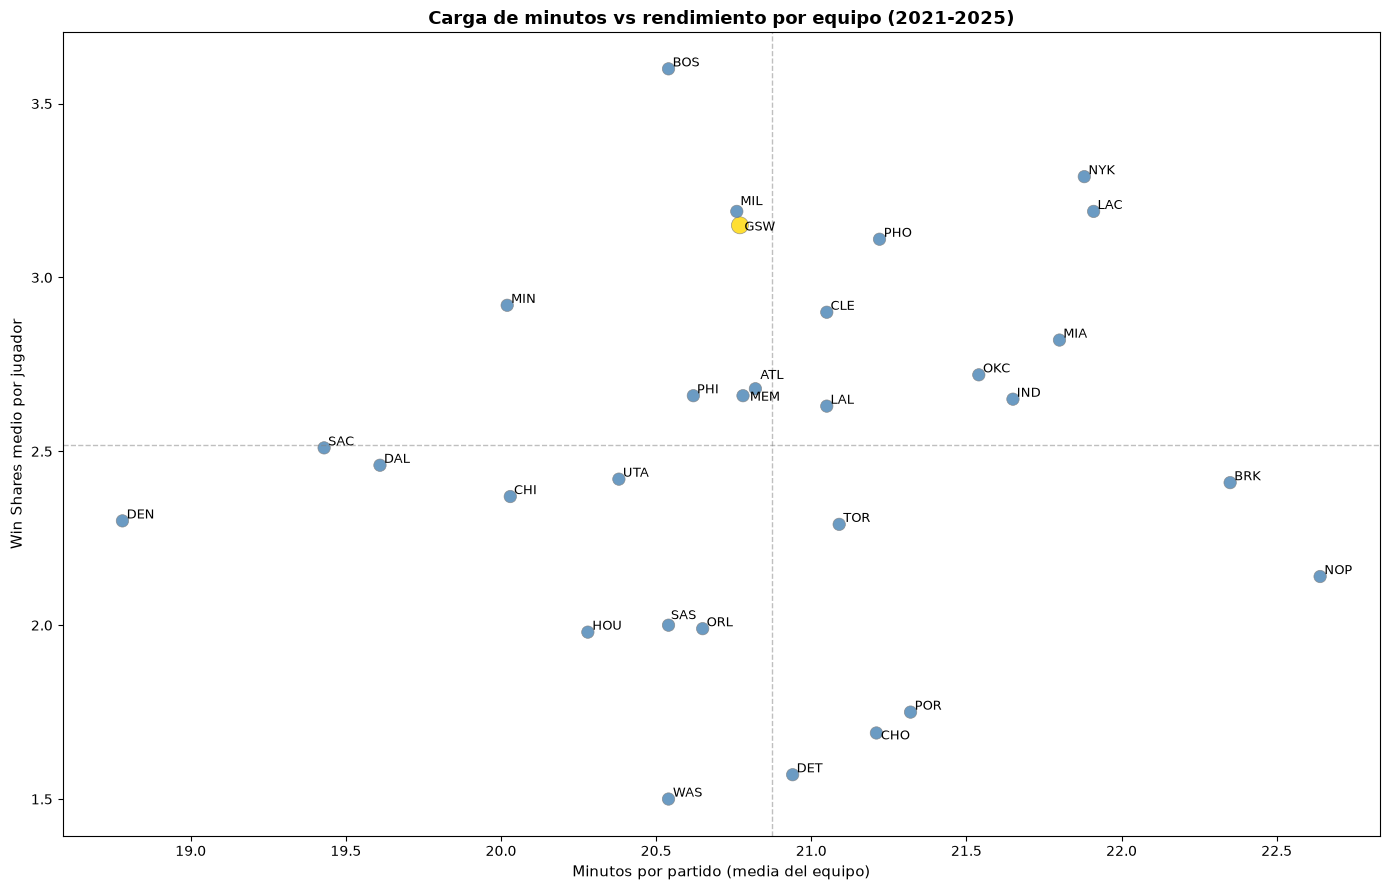

In [258]:
# Scatter plot: minutos por partido vs ws_medio por equipo para identificar si más carga implica más o menos rendimiento.
plt.figure(figsize=(14, 9))

# Coloreamos GSW de forma destacada.
colores = ['gold' if t == 'GSW' else 'steelblue' for t in carga_equipo['team']]
tamaños = [150 if t == 'GSW' else 80 for t in carga_equipo['team']]

plt.scatter(carga_equipo['minutos_por_partido'], carga_equipo['ws_medio'],
            c=colores, s=tamaños, alpha=0.8, edgecolors='gray', linewidth=0.5)

# Etiquetamos todos los equipos.
from adjustText import adjust_text
texts = []
for _, row in carga_equipo.iterrows():
    texts.append(plt.annotate(row['team'],
                              xy=(row['minutos_por_partido'], row['ws_medio']),
                              fontsize=9))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Líneas de referencia en la media de la liga.
plt.axvline(x=carga_equipo['minutos_por_partido'].mean(),
            color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.axhline(y=carga_equipo['ws_medio'].mean(),
            color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.title('Carga de minutos vs rendimiento por equipo (2021-2025)',
          fontsize=13, fontweight='bold')
plt.xlabel('Minutos por partido (media del equipo)', fontsize=11)
plt.ylabel('Win Shares medio por jugador', fontsize=11)
plt.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

### Carga de minutos vs rendimiento por equipo (2021-2025)

El gráfico divide la liga en cuatro cuadrantes según las medias de la liga en minutos por partido y Win Shares medio por jugador.

**Cuadrante superior izquierdo (menos carga, más rendimiento):** 
la zona ideal. GSW se sitúa aquí junto a BOS y MIL, lo que indica que estos equipos obtienen alto rendimiento sin sobrecargar a sus jugadores. BOS destaca como el caso más extremo: el mayor ws_medio de la liga con una carga de minutos moderada.

**Cuadrante superior derecho (más carga, más rendimiento):** 
equipos como NYK, LAC o MIA que obtienen buen rendimiento pero a costa de una mayor exigencia física sobre sus jugadores. Este modelo tiene más riesgo de lesiones y caída de rendimiento en tramos finales de temporada.

**Cuadrante inferior derecho (más carga, menos rendimiento):** 
la peor combinación. NOP, BRK, POR y CHO cargan mucho a sus jugadores y obtienen rendimientos por debajo de la media. Son equipos en reconstrucción o con gestión de rotaciones ineficiente.

**Cuadrante inferior izquierdo (menos carga, menos rendimiento):** 
equipos como WAS, HOU o DEN que rotan ampliamente pero no consiguen traducirlo en rendimiento. La rotación excesiva puede diluir el tiempo de jugadores clave.

GSW ocupa la posición más eficiente del gráfico: extrae más rendimiento por minuto jugado que la mayoría de equipos de la liga, lo que habla favorablemente de la gestión de rotaciones del coaching staff.

In [259]:
def carga_individual_gsw(df_min, temporadas_recientes=2021):
    # Filtramos jugadores de GSW en temporadas recientes.
    df_gsw_min = df_min[(df_min['team'] == 'GSW') & 
                        (df_min['season'] >= temporadas_recientes)].copy()
    
    # Calculamos la media de minutos por partido y ws por jugador.
    # Para la edad tomamos el último valor registrado.
    edad_actual = (df_gsw_min.groupby('player')['age']
                   .last()
                   .reset_index()
                   .rename(columns={'age': 'edad_actual'}))
    
    resumen = (df_gsw_min.groupby('player')
               .agg(
                   temporadas=('season', 'count'),
                   minutos_por_partido=('minutos_por_partido', 'mean'),
                   minutos_totales=('minutos_totales', 'mean'),
                   ws_medio=('ws', 'mean')
               )
               .round(2)
               .reset_index())
    
    resumen = resumen.merge(edad_actual, on='player')
    resumen = resumen.sort_values('minutos_por_partido', ascending=False).reset_index(drop=True)
    
    print(resumen.to_string())
    return resumen

resumen_gsw_min = carga_individual_gsw(df_minutos)

                    player  temporadas  minutos_por_partido  minutos_totales  ws_medio  edad_actual
0            Stephen Curry           5                33.66          2195.40      7.98           36
1             Jimmy Butler           1                31.70          1746.00      8.70           35
2           Andrew Wiggins           4                31.10          1950.75      3.52           28
3            Klay Thompson           3                30.70          1834.67      2.83           33
4           Draymond Green           5                29.64          1816.20      4.04           34
5       Brandin Podziemski           2                26.70          1842.00      4.15           21
6             Jordan Poole           3                26.47          1909.67      3.70           23
7               Chris Paul           1                26.40          1531.00      4.30           38
8         Donte DiVincenzo           1                26.30          1894.00      4.20           26


### Carga individual de jugadores GSW (2021-2025)

Stephen Curry lidera el ranking de minutos por partido con 33.66 de media a lo largo de 5 temporadas, con una edad media de 34 años. Es el jugador más utilizado del roster y el de mayor edad entre los titulares habituales, lo que representa el principal riesgo físico del equipo. Draymond Green completa el mismo perfil: 5 temporadas, 29.64 minutos por partido y 32 años de media. Ambos son irremplazables en el sistema de juego de GSW pero su carga acumulada es una señal de alerta a medio plazo.

Klay Thompson acumuló 30.70 minutos por partido en sus 3 temporadas del período analizado pese a haber sufrido lesiones graves previas, lo que cuestiona si la gestión de su carga fue la adecuada teniendo en cuenta su historial.

En el lado positivo, Trayce Jackson-Davis y Brandin Podziemski, los dos jugadores más infravalorados identificados en el Bloque 2, reciben una carga moderada (16.10 y 26.70 minutos respectivamente) acorde a su rol en el equipo. Kuminga, con 22.08 minutos en 4 temporadas y 20.5 años de media, tiene margen para asumir más protagonismo sin comprometer su desarrollo físico.

Kevon Looney destaca como el jugador más eficiente en términos de carga-rendimiento: 5 temporadas con solo 19.02 minutos por partido y un ws_medio de 5.44, el más alto del roster. Es el ejemplo perfecto de un jugador al que GSW ha sabido gestionar correctamente: suficientes minutos para rendir, sin sobrecargarle.

In [260]:
# Exportamos la tabla de carga por equipo para el dashboard de coaching en Power BI
carga_equipo.to_csv('data/pbi_carga_minutos_equipos.csv', index=False, decimal=',')
print(f'Exportado: data/pbi_carga_minutos_equipos.csv')
print(f'Shape: {carga_equipo.shape}')

# Exportamos la tabla de carga individual de jugadores GSW
resumen_gsw_min.to_csv('data/pbi_carga_minutos_gsw.csv', index=False, decimal=',')
print(f'Exportado: data/pbi_carga_minutos_gsw.csv')
print(f'Shape: {resumen_gsw_min.shape}')

# Exportamos el dataset completo de minutos por jugador para análisis individual
cols_minutos = ['player', 'season', 'team', 'pos', 'age',
                'minutos_totales', 'partidos_totales',
                'minutos_por_partido', 'ws', 'per']
df_minutos[cols_minutos].to_csv('data/pbi_carga_minutos_jugadores.csv', index=False, decimal=',')
print(f'Exportado: data/pbi_carga_minutos_jugadores.csv')
print(f'Shape: {df_minutos[cols_minutos].shape}')

Exportado: data/pbi_carga_minutos_equipos.csv
Shape: (30, 4)
Exportado: data/pbi_carga_minutos_gsw.csv
Shape: (36, 6)
Exportado: data/pbi_carga_minutos_jugadores.csv
Shape: (6392, 10)


In [263]:
# Vamos a hacer una comprobación con las siglas de los equipos para crear un diccionario.
print(df_mercado_pbi['team'].unique())

<ArrowStringArray>
['LAL', 'MIA', 'NYK', 'SAS', 'CLE', 'DAL', 'BOS', 'ORL', 'MIL', 'UTA', 'PHO',
 'WAS', 'MEM', 'DEN', 'TOR', 'ATL', 'PHI', 'NOH', 'CHI', 'LAC', 'MIN', 'CHA',
 'DET', 'NJN', 'IND', 'GSW', 'HOU', 'POR', 'SAC', 'OKC', 'BRK', 'NOP', 'CHO']
Length: 33, dtype: str


In [261]:
# Creamos un diccionario con los 30 equipos NBA, su ciudad, latitud y longitud para poder incluir una gráfica de mapa en el PBI.
equipos_coordenadas = {
    'ATL': ('Atlanta Hawks', 'Atlanta', 33.7573, -84.3963),
    'BOS': ('Boston Celtics', 'Boston', 42.3662, -71.0621),
    'BRK': ('Brooklyn Nets', 'Brooklyn', 40.6828, -73.9752),
    'CHA': ('Charlotte Hornets', 'Charlotte', 35.2251, -80.8392),
    'CHI': ('Chicago Bulls', 'Chicago', 41.8807, -87.6742),
    'CLE': ('Cleveland Cavaliers', 'Cleveland', 41.4965, -81.6882),
    'DAL': ('Dallas Mavericks', 'Dallas', 32.7905, -96.8103),
    'DEN': ('Denver Nuggets', 'Denver', 39.7487, -105.0077),
    'DET': ('Detroit Pistons', 'Detroit', 42.3410, -83.0552),
    'GSW': ('Golden State Warriors', 'San Francisco', 37.7680, -122.3877),
    'HOU': ('Houston Rockets', 'Houston', 29.7508, -95.3621),
    'IND': ('Indiana Pacers', 'Indianapolis', 39.7640, -86.1555),
    'LAC': ('LA Clippers', 'Los Angeles', 34.0430, -118.2673),
    'LAL': ('LA Lakers', 'Los Angeles', 34.0430, -118.2673),
    'MEM': ('Memphis Grizzlies', 'Memphis', 35.1382, -90.0505),
    'MIA': ('Miami Heat', 'Miami', 25.7814, -80.1870),
    'MIL': ('Milwaukee Bucks', 'Milwaukee', 43.0450, -87.9170),
    'MIN': ('Minnesota Timberwolves', 'Minneapolis', 44.9795, -93.2760),
    'NOP': ('New Orleans Pelicans', 'New Orleans', 29.9490, -90.0821),
    'NYK': ('New York Knicks', 'New York', 40.7505, -73.9934),
    'OKC': ('Oklahoma City Thunder', 'Oklahoma City', 35.4634, -97.5151),
    'ORL': ('Orlando Magic', 'Orlando', 28.5392, -81.3839),
    'PHI': ('Philadelphia 76ers', 'Philadelphia', 39.9012, -75.1720),
    'PHO': ('Phoenix Suns', 'Phoenix', 33.4457, -112.0712),
    'POR': ('Portland Trail Blazers', 'Portland', 45.5316, -122.6668),
    'SAC': ('Sacramento Kings', 'Sacramento', 38.5802, -121.4997),
    'SAS': ('San Antonio Spurs', 'San Antonio', 29.4270, -98.4375),
    'TOR': ('Toronto Raptors', 'Toronto', 43.6435, -79.3791),
    'UTA': ('Utah Jazz', 'Salt Lake City', 40.7683, -111.9011),
    'WAS': ('Washington Wizards', 'Washington', 38.8981, -77.0209),
    'CHO': ('Charlotte Hornets', 'Charlotte', 35.2251, -80.8392),
}

# Creamos el dataframe
df_coordenadas = pd.DataFrame.from_dict(
    equipos_coordenadas,
    orient='index',
    columns=['nombre_completo', 'ciudad', 'latitud', 'longitud']
).reset_index().rename(columns={'index': 'team'})

print(df_coordenadas.to_string())
print(f'\nShape: {df_coordenadas.shape}')

   team         nombre_completo          ciudad  latitud  longitud
0   ATL           Atlanta Hawks         Atlanta  33.7573  -84.3963
1   BOS          Boston Celtics          Boston  42.3662  -71.0621
2   BRK           Brooklyn Nets        Brooklyn  40.6828  -73.9752
3   CHA       Charlotte Hornets       Charlotte  35.2251  -80.8392
4   CHI           Chicago Bulls         Chicago  41.8807  -87.6742
5   CLE     Cleveland Cavaliers       Cleveland  41.4965  -81.6882
6   DAL        Dallas Mavericks          Dallas  32.7905  -96.8103
7   DEN          Denver Nuggets          Denver  39.7487 -105.0077
8   DET         Detroit Pistons         Detroit  42.3410  -83.0552
9   GSW   Golden State Warriors   San Francisco  37.7680 -122.3877
10  HOU         Houston Rockets         Houston  29.7508  -95.3621
11  IND          Indiana Pacers    Indianapolis  39.7640  -86.1555
12  LAC             LA Clippers     Los Angeles  34.0430 -118.2673
13  LAL               LA Lakers     Los Angeles  34.0430 -118.

In [264]:
# Añadimos las franquicias históricas que aparecen en el dataset, pero que ahora ya no se llaman así porque se han mudado de ciudad.
equipos_extra = {
    'NJN': ('New Jersey Nets', 'Newark', 40.7357, -74.1724),
    'NOH': ('New Orleans Hornets', 'New Orleans', 29.9490, -90.0821),
}

# Añadimos al dataframe existente.
df_extra = pd.DataFrame.from_dict(
    equipos_extra,
    orient='index',
    columns=['nombre_completo', 'ciudad', 'latitud', 'longitud']
).reset_index().rename(columns={'index': 'team'})

df_coordenadas = pd.concat([df_coordenadas, df_extra], ignore_index=True)

# Verificamos que están todos los equipos del dataset.
equipos_dataset = set(df_mercado_pbi['team'].unique())
equipos_coordenadas = set(df_coordenadas['team'].unique())

print('Equipos en dataset sin coordenadas:')
print(equipos_dataset - equipos_coordenadas)
print(f'\nShape final: {df_coordenadas.shape}')

Equipos en dataset sin coordenadas:
set()

Shape final: (33, 5)


In [265]:
# Merge del dataset de mercado con las coordenadas de equipos
df_mercado_pbi = pd.read_csv('data/pbi_mercado_nba.csv')
df_mercado_pbi = df_mercado_pbi.merge(
    df_coordenadas[['team', 'nombre_completo', 'ciudad', 'latitud', 'longitud']],
    on='team', how='left'
)

# Verificamos que el merge ha funcionado
print(f'Nulos en latitud: {df_mercado_pbi["latitud"].isnull().sum()}')
print(f'Shape final: {df_mercado_pbi.shape}')

# Exportamos con decimal=',' para que Power BI lo lea correctamente
df_mercado_pbi.to_csv('data/pbi_mercado_nba.csv', index=False, decimal=',')
print('Exportado: data/pbi_mercado_nba.csv')

Nulos en latitud: 0
Shape final: (6392, 15)
Exportado: data/pbi_mercado_nba.csv


### Conclusiones del Bloque 3: Gestión de carga de minutos

Tres conclusiones accionables para GSW:

1. **La gestión de rotaciones de GSW es eficiente a nivel de equipo.**
   Con 20.77 minutos por partido de media, GSW se sitúa por debajo de la media de la liga y obtiene un ws_medio superior. Es uno de los pocos equipos que combina rotación amplia con rendimiento por encima de la media, lo que habla favorablemente del coaching staff.

2. **Stephen Curry y Draymond Green son el principal riesgo físico del roster.** 
   Ambos acumulan las cargas más altas del equipo con más de 30 y 29 minutos por partido respectivamente, en edades donde la recuperación es más lenta. Reducir gradualmente su carga sin sacrificar rendimiento es el reto más inmediato para el coaching staff.

3. **Kevon Looney es el modelo de gestión a seguir dentro del roster.**
   Con la carga más baja entre los jugadores habituales y el ws_medio más alto del equipo, su caso demuestra que en GSW la eficiencia no requiere acumulación de minutos. Aplicar esa misma lógica a jugadores jóvenes como Kuminga o Podziemski puede maximizar su desarrollo sin comprometer su salud a largo plazo.

## Propuestas para la dirección de Golden State Warriors

El análisis de valor de mercado, roster y gestión de carga de minutos permite formular seis propuestas concretas ordenadas por urgencia.

---

### 1. Renovar a Trayce Jackson-Davis antes de que llegue a la agencia libre
Es el jugador con mejor ratio de valor del roster (4.16 ws/millón) y tiene contrato de rookie. El análisis histórico demuestra que este perfil de jugador es el que más se encarece en el mercado una vez llega a la agencia libre. La renovación debe ser prioritaria en la próxima offseason.

### 2. Renovar a Brandin Podziemski con cautela
Aparece como infravalorado de forma sostenida en 2024 y 2025, pero su progresión no es tan clara como la de Jackson-Davis. Se recomienda una renovación a precio de mercado medio, sin comprometer el salary cap con un contrato máximo prematuro.

### 3. Definir el futuro de Jonathan Kuminga en la próxima temporada
Kuminga está en el umbral entre infravalorado y valor de mercado. La próxima temporada debe usarse como período de evaluación definitivo antes de ofrecerle un contrato largo. Si su rendimiento no mejora, GSW debe explorar su valor en el mercado de traspasos.

### 4. Explorar el mercado de pívots infravalorados para reforzar el roster
El análisis de mercado confirma que los pívots son la posición con mejor retorno por dólar invertido de la liga. Con el salary cap comprometido, fichajes de bajo coste en esta posición ofrecen la mayor eficiencia posible para reforzar el equipo.

### 5. Gestionar la carga de Curry y Green con criterio médico
Con 36 y 34 años respectivamente y las cargas más altas del roster, ambos jugadores necesitan un plan de gestión de minutos que preserve su rendimiento en playoffs sin comprometer su salud durante la temporada regular. Reducir entre 2 y 3 minutos por partido su carga media podría ser suficiente para marcar la diferencia en la segunda mitad de temporada.

### 6. Mantener el modelo de rotación actual del coaching staff
GSW es uno de los equipos más eficientes de la liga en la combinación carga-rendimiento. El modelo de rotación amplia con Kevon Looney como referencia de eficiencia debe mantenerse y extenderse a los jugadores jóvenes del roster para maximizar su desarrollo sin comprometer su salud a largo plazo.